# Fraud Detection in Electricity and Gas Consumption Challenge

This is a simple starter notebook based on the tutorial prepared by Joy Wawira. Check out the article [here](https://zindi.africa/learn/fraud-detection-in-electricity-and-gas-consumption-challenge-tutorial) for a more detailed description of the steps taken.

This notebook covers:
- Downloading the data straight from Zindi and onto colab
- Loading the data and carrying out simple EDA to understand the data and prepare for modelling 
- Preprocessing the data and feature engineering 
- Creating a simple LGBM model and predicting on the test set
- Prepare submission file and save as csv
- Some tips on how to improve model performance and your score

# Pre-Requisites

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Download and extract files

In [2]:
client_train = pd.read_csv('data/train/client_train.csv', low_memory=False)

In [3]:
invoice_train = pd.read_csv('data/train/invoice_train.csv', low_memory=False)

In [4]:
client_test = pd.read_csv('data/test/client_test.csv', low_memory=False)

In [5]:
invoice_test = pd.read_csv('data/test/invoice_test.csv', low_memory=False)

# Data Prep

## Import Libraries

## Read the Data

## Data Understanding

In [6]:
#compare size of the various datasets
print(client_train.shape, invoice_train.shape, client_test.shape, invoice_train.shape)

(135493, 6) (4476749, 16) (58069, 5) (4476749, 16)


In [7]:
client_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [8]:
client_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

In [9]:
client_train.target.unique()

array([0., 1.])

In [10]:
invoice_train.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [11]:
invoice_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [12]:
invoice_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tarif_type,4476749.0,2.012804e+01,1.347256e+01,8.0,11.0,11.0,40.0,4.500000e+01
counter_number,4476749.0,1.230587e+11,1.657267e+12,0.0,121108.0,494561.0,1115161.0,2.798115e+13
counter_code,4476749.0,1.724884e+02,1.338871e+02,0.0,5.0,203.0,207.0,6.000000e+02
reading_remarque,4476749.0,7.321702e+00,1.571654e+00,5.0,6.0,8.0,9.0,4.130000e+02
counter_coefficient,4476749.0,1.003040e+00,3.083466e-01,0.0,1.0,1.0,1.0,5.000000e+01
consommation_level_1,4476749.0,4.109795e+02,7.573080e+02,0.0,79.0,274.0,600.0,9.999100e+05
consommation_level_2,4476749.0,1.093225e+02,1.220123e+03,0.0,0.0,0.0,0.0,9.990730e+05
consommation_level_3,4476749.0,2.030620e+01,1.574239e+02,0.0,0.0,0.0,0.0,6.449200e+04
consommation_level_4,4476749.0,5.292588e+01,8.754725e+02,0.0,0.0,0.0,0.0,5.479460e+05
old_index,4476749.0,1.776700e+04,4.036693e+04,0.0,1791.0,7690.0,21660.0,2.800280e+06


In [13]:
counter_stats = invoice_train.groupby('counter_type')[
    ['consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4']
].agg(['mean', 'max', 'std'])

print(counter_stats.T)

counter_type                        ELEC            GAZ
consommation_level_1 mean     507.918803     197.348707
                     max    99920.000000  999910.000000
                     std      597.984711     991.476389
consommation_level_2 mean     158.122399       1.779250
                     max   999073.000000   29806.000000
                     std     1466.627210     111.135413
consommation_level_3 mean      29.520556       0.000000
                     max    64492.000000       0.000000
                     std      189.091928       0.000000
consommation_level_4 mean      76.942075       0.000000
                     max   547946.000000       0.000000
                     std     1054.702565       0.000000


In [14]:
for col in invoice_train.columns:
    print(f"{col} - {invoice_train[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [15]:
invoice_train.counter_coefficient.value_counts()

counter_coefficient
1     4475102
2         886
3         321
40        197
30        137
0          46
6          30
4          12
10          6
20          3
9           3
50          2
33          1
5           1
11          1
8           1
Name: count, dtype: int64

No missing values in train set

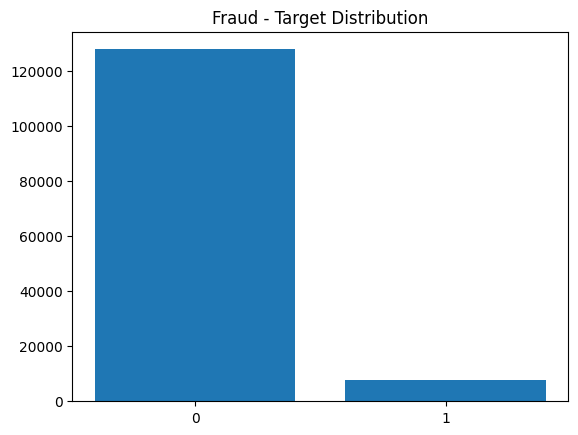

In [16]:
fraudactivities = client_train.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index, height=fraudactivities.values, tick_label = [0,1])
plt.title('Fraud - Target Distribution')
plt.show()

Target is highly imbalanced with fewer cases of fraudulent activities

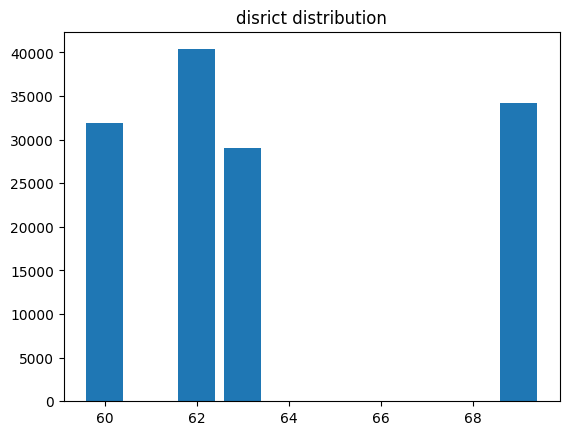

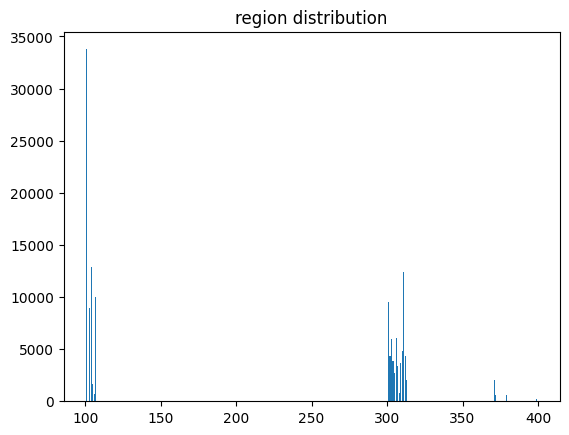

In [17]:
#Visualize client distribution across districts and regions
for col in ['disrict','region']:
    region = client_train.groupby([col])['client_id'].count()
    plt.bar(x=region.index, height=region.values)
    plt.title(col+' distribution')
    plt.show()

## Feature Engineering

In [18]:
#convert the column invoice_date to date time format on both the invoice train and invoice test
for df in [invoice_train,invoice_test]:
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [19]:
#encode labels in categorical column
d={"ELEC":0,"GAZ":1}
invoice_train['counter_type']=invoice_train['counter_type'].map(d)
invoice_test['counter_type']=invoice_test['counter_type'].map(d)

In [20]:
#convert categorical columns to int for model
client_train['client_catg'] = client_train['client_catg'].astype(int)
client_train['disrict'] = client_train['disrict'].astype(int)

client_test['client_catg'] = client_test['client_catg'].astype(int)
client_test['disrict'] = client_test['disrict'].astype(int)

In [21]:
# find consumption levels and amounts for each clients
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['consommation_level_1'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_2'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_3'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_4'] = ['mean', 'max', 'min', 'std', 'sum']

    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = [''.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (invoice_data.groupby('client_id')
            .size()
            .reset_index(name='{}transactions_count'.format('1')))
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [22]:
agg_train = aggregate_by_client_id(invoice_train)

print(agg_train.shape)
agg_train.head()

(135493, 22)


,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3mean,consommation_level_3max,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,117.357143,800,0,289.433294,1643,36.714286,382,0,105.421081,514


In [23]:
# calculate the consumption from the counter's index
invoice_train['calc_index'] = invoice_train['new_index'] - invoice_train['old_index']

In [24]:
# aggregate each invoice's index for each client
calc_index_sum = invoice_train.groupby('client_id')['calc_index'].sum()

agg_train_index = pd.merge(agg_train, calc_index_sum, on='client_id', how='left')

agg_train_index.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3max,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,12704
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,20629
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,15057
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,24
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,800,0,289.433294,1643,36.714286,382,0,105.421081,514,12917


In [25]:
# we want to know the last tarif the client uses to interpret the consumption levels
calc_tarif_type = invoice_train.groupby('client_id')['tarif_type'].last()

agg_train_tarif = pd.merge(agg_train_index, calc_tarif_type, on='client_id', how='left')

In [26]:
agg_train_tarif.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,12704,11
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,20629,11
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,15057,11
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,24,11
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,0,289.433294,1643,36.714286,382,0,105.421081,514,12917,11


In [27]:
## we want to know the counter coefficienct of the client uses to interpret the consumption levels

calc_counter_coeff = invoice_train.groupby('client_id')['counter_coefficient'].last()

agg_train_coeff = pd.merge(agg_train_tarif, calc_counter_coeff, on='client_id', how='left')

In [28]:
agg_train_coeff.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0.000000,0,0,0.000000,0,12704,11,1
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0.000000,0,0,0.000000,0,20629,11,1
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0.000000,0,0,0.000000,0,15057,11,1
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0.000000,0,0,0.000000,0,24,11,1
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,289.433294,1643,36.714286,382,0,105.421081,514,12917,11,1


In [29]:
agg_train_coeff.counter_coefficient.value_counts()

counter_coefficient
1     135455
2         20
3          9
40         2
6          2
50         1
20         1
30         1
4          1
0          1
Name: count, dtype: int64

In [30]:
energy_features = (
    invoice_train
    .groupby('client_id')['counter_type']
    .agg(
        has_electricity=lambda x: int((x == 0).any()),
        has_gas=lambda x: int((x == 1).any())
    )
    .reset_index()
)

In [31]:
energy_features

,client_id,has_electricity,has_gas
0,train_Client_0,1,0
1,train_Client_1,1,0
2,train_Client_10,1,0
3,train_Client_100,1,0
4,train_Client_1000,1,0
...,...,...,...
135488,train_Client_99995,1,1
135489,train_Client_99996,1,1
135490,train_Client_99997,1,1
135491,train_Client_99998,1,0


In [32]:
agg_train_all = pd.merge(agg_train_coeff, energy_features, on='client_id', how='left')
agg_train_all

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,train_Client_99995,71,1.957746,139,0,16.496265,139,0.000000,0,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,train_Client_99996,41,185.853659,800,0,200.935258,7620,0.756098,31,0,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,train_Client_99997,36,273.083333,1075,33,211.123441,9831,0.000000,0,0,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,train_Client_99998,2,300.000000,400,200,141.421356,600,70.500000,135,6,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [33]:
aggregated_manually = pd.merge(client_train,agg_train_all, on='client_id', how='left')

In [34]:
aggregated_manually

,disrict,client_id,client_catg,region,creation_date,target,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,...,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,train_Client_0,11,101,31/12/1994,0.0,35,352.400000,1200,38,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,557.540541,1207,190,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,798.611111,2400,188,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,1.200000,15,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,663.714286,800,124,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,1.957746,139,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,185.853659,800,0,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,273.083333,1075,33,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,300.000000,400,200,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [69]:
def agg_merged_datasets(client, invoice):

    # --- aggregation consumption levels ---
    aggs = {}
    aggs['consommation_level_1'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_2'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_3'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_4'] = ['mean', 'max', 'min', 'std', 'sum']

    agg_trans = invoice.groupby('client_id').agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    # --- number of transactions per client ---
    df = (
        invoice.groupby('client_id')
        .size()
        .reset_index(name='transactions_count')
    )

    agg_data = pd.merge(df, agg_trans, on='client_id', how='left')

    # --- calc_index feature ---
    invoice['calc_index'] = invoice['new_index'] - invoice['old_index']

    calc_index_sum = (
        invoice.groupby('client_id')['calc_index']
        .sum()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_index_sum, on='client_id', how='left')

    # --- tarif type ---
    calc_tarif_type = (
        invoice.groupby('client_id')['tarif_type']
        .last()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_tarif_type, on='client_id', how='left')

    # --- counter coefficient ---
    calc_counter_coeff = (
        invoice.groupby('client_id')['counter_coefficient']
        .last()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_counter_coeff, on='client_id', how='left')

    # --- electricity / gas features ---
    energy_features = (
        invoice
        .groupby('client_id')['counter_type']
        .agg(
            has_electricity=lambda x: int((x == 0).any()),
            has_gas=lambda x: int((x == 1).any())
        )
        .reset_index()
    )

    agg_data = pd.merge(agg_data, energy_features, on='client_id', how='left')

    # --- merge with client table ---
    final_df = pd.merge(client, agg_data, on='client_id', how='left')

    return final_df

In [70]:
train_combined = agg_merged_datasets(client_train, invoice_train)

In [52]:
train_combined.shape

(135493, 32)

In [43]:
test_combined = agg_merged_datasets(client_test, invoice_test)

In [53]:
test_combined.shape

(58069, 31)

In [56]:
train_combined 

,disrict,client_id,client_catg,region,creation_date,target,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,train_Client_0,11,101,31/12/1994,0.0,35,352.400000,1200,38,...,0.000000,0,0,0.000000,0,12704,11,NaN,1,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,557.540541,1207,190,...,0.000000,0,0,0.000000,0,20629,11,NaN,1,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,798.611111,2400,188,...,0.000000,0,0,0.000000,0,15057,11,NaN,1,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,1.200000,15,0,...,0.000000,0,0,0.000000,0,24,11,NaN,1,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,663.714286,800,124,...,36.714286,382,0,105.421081,514,12917,11,NaN,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,1.957746,139,0,...,0.000000,0,0,0.000000,0,0,11,NaN,1,1
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,185.853659,800,0,...,0.000000,0,0,0.000000,0,7651,40,NaN,1,1
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,273.083333,1075,33,...,0.000000,0,0,0.000000,0,9831,11,NaN,1,1
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,300.000000,400,200,...,0.000000,0,0,0.000000,0,741,10,NaN,1,0


In [74]:
X_train = train_combined.drop(columns=['client_id', 'creation_date', 'target'])
X_train

,disrict,client_catg,region,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,consommation_level_1_sum,consommation_level_2_mean,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,11,101,35,352.400000,1200,38,310.343472,12334,10.571429,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,69,11,107,37,557.540541,1207,190,197.935960,20629,0.000000,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,62,11,301,18,798.611111,2400,188,513.841374,14375,37.888889,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,69,11,105,20,1.200000,15,0,3.607011,24,0.000000,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,62,11,303,14,663.714286,800,124,224.831365,9292,104.857143,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,11,304,71,1.957746,139,0,16.496265,139,0.000000,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,63,11,311,41,185.853659,800,0,200.935258,7620,0.756098,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,63,11,311,36,273.083333,1075,33,211.123441,9831,0.000000,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,60,11,101,2,300.000000,400,200,141.421356,600,70.500000,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [75]:
y_train = train_combined['target']
y_train

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
135488    0.0
135489    0.0
135490    0.0
135491    0.0
135492    0.0
Name: target, Length: 135493, dtype: float64

In [76]:
X_test = test_combined.drop(columns=['client_id', 'creation_date'])
X_test

,disrict,client_catg,region,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,consommation_level_1_sum,consommation_level_2_mean,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,62,11,307,37,488.135135,1090,0,230.388942,18061,3.243243,...,0.000000,0,0,0.000000,0,18181,11,1,1,0
1,69,11,103,22,1091.409091,3600,11,739.185437,24011,843.136364,...,586.318182,12899,0,2750.076040,12899,59470,11,1,1,0
2,62,11,310,74,554.040541,1200,0,346.775891,40999,37.364865,...,0.162162,12,0,1.394972,12,44941,40,1,1,1
3,60,11,101,40,244.350000,721,0,247.253171,9774,0.000000,...,0.000000,0,0,0.000000,0,9774,11,1,1,1
4,62,11,301,53,568.188679,2400,0,486.891871,30114,145.056604,...,0.000000,0,0,0.000000,0,39703,11,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58064,63,11,399,4,461.250000,938,0,532.755964,1845,0.000000,...,0.000000,0,0,0.000000,0,1845,11,1,1,1
58065,63,11,311,46,181.565217,456,0,107.556838,8352,0.000000,...,0.000000,0,0,0.000000,0,8352,40,1,1,1
58066,60,11,101,59,160.559322,739,22,104.969334,9473,11.932203,...,0.000000,0,0,0.000000,0,10177,10,1,1,1
58067,60,11,101,1,800.000000,800,800,NaN,800,400.000000,...,0.000000,0,0,NaN,0,1927,11,1,1,0


In [79]:
# Categorical Features (Categories, IDs, and Binary flags)
cat_cols = [
    'disrict', 
    'client_catg', 
    'region', 
    'tarif_type', 
    'counter_coefficient', 
    'has_electricity', 
    'has_gas'
]

# Numerical Features (All aggregated consumption stats)
# We exclude the target, date, and client_id (which we drop anyway)
num_cols = [col for col in X_train.columns if col not in cat_cols]

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer


In [89]:
num_cols

['transactions_count',
 'consommation_level_1_mean',
 'consommation_level_1_max',
 'consommation_level_1_min',
 'consommation_level_1_std',
 'consommation_level_1_sum',
 'consommation_level_2_mean',
 'consommation_level_2_max',
 'consommation_level_2_min',
 'consommation_level_2_std',
 'consommation_level_2_sum',
 'consommation_level_3_mean',
 'consommation_level_3_max',
 'consommation_level_3_min',
 'consommation_level_3_std',
 'consommation_level_3_sum',
 'consommation_level_4_mean',
 'consommation_level_4_max',
 'consommation_level_4_min',
 'consommation_level_4_std',
 'consommation_level_4_sum',
 'calc_index']

In [91]:
X_train.isna().sum()

disrict                         0
client_catg                     0
region                          0
transactions_count              0
consommation_level_1_mean       0
consommation_level_1_max        0
consommation_level_1_min        0
consommation_level_1_std     4212
consommation_level_1_sum        0
consommation_level_2_mean       0
consommation_level_2_max        0
consommation_level_2_min        0
consommation_level_2_std     4212
consommation_level_2_sum        0
consommation_level_3_mean       0
consommation_level_3_max        0
consommation_level_3_min        0
consommation_level_3_std     4212
consommation_level_3_sum        0
consommation_level_4_mean       0
consommation_level_4_max        0
consommation_level_4_min        0
consommation_level_4_std     4212
consommation_level_4_sum        0
calc_index                      0
tarif_type                      0
counter_coefficient             0
has_electricity                 0
has_gas                         0
dtype: int64

In [92]:
# 1. Define Column Groups (ensure these match your dataframe exactly)
cat_cols = ['disrict', 'client_catg', 'region', 'tarif_type', 
            'counter_coefficient', 'has_electricity', 'has_gas']

num_cols = [col for col in X_train.columns if col not in cat_cols 
            and col not in ['client_id', 'creation_date', 'target']]

# 2. Define the Processor (The Pipelines)
cat_pipeline = Pipeline(steps=[
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', RobustScaler())
])

# 3. Create the Master Processor
processor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ],
    remainder='drop'
)

# --- EXECUTION ---
# This one line now does ALL the work:
X_train_processed = processor.fit_transform(X_train)

In [93]:
X_test_processed = processor.transform(X_test)

C:\Users\Zeynep\Desktop\DS\ds-ml-project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Modelling

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Instantiate the model
# 'balanced' automatically adjusts weights inversely proportional to class frequencies
logreg = LogisticRegression(
    class_weight='balanced', 
    max_iter=5000,          
    random_state=42
)

# 2. Fit the model on processed training data
logreg.fit(X_train_processed, y_train)

# 3. Predict on the processed test data
y_pred = logreg.predict(X_test_processed)
y_prob = logreg.predict_proba(X_test_processed)[:, 1] # Probabilities for AUC

C:\Users\Zeynep\Desktop\DS\ds-ml-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
logreg = LogisticRegression(
    class_weight='balanced', 
    max_iter=5000, 
    solver='saga', 
    penalty='l1',           # 'l1' (Lasso) is great for selecting only important features
    n_jobs=-1,
    random_state=42
)

logreg.fit(X_train_processed, y_train)

# 3. Predict on the processed test data
y_pred = logreg.predict(X_test_processed)
y_prob = logreg.predict_proba(X_test_processed)[:, 1] 

In [99]:
# If you have the true labels for the test set (y_test):
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

--- Confusion Matrix ---


NameError: name 'y_test' is not defined

## Train LGBM *Classifier*

In [ ]:
x_train = train.drop(columns=['target'])
y_train = train['target']

In [ ]:
model = LGBMClassifier(boosting_type='gbdt', num_iterationss=500)
model.fit(x_train, y_train)

LGBMClassifier(num_iterationss=500)

In [ ]:
x_train.disrict.unique()

array([60, 69, 62, 63])

## Make Predictions on test set

In [ ]:
test.columns

Index(['disrict', 'client_catg', 'region', '1transactions_count',
       'consommation_level_1_mean', 'consommation_level_2_mean',
       'consommation_level_3_mean', 'consommation_level_4_mean'],
      dtype='object')

In [ ]:
preds = model.predict(test)
preds = pd.DataFrame(preds, columns=['target'])
preds.head()

,target
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
submission = pd.DataFrame(
    {
        'client_id': sub_client_id,
        'target': preds['target']
    }
)

submission.head()

,client_id,target
0,test_Client_0,0.0
1,test_Client_1,0.0
2,test_Client_10,0.0
3,test_Client_100,0.0
4,test_Client_1000,0.0


In [ ]:
submission.to_csv(f'{OUTPUT_DIR}/submission.csv', index=False)

## Tips 
- Thorough EDA and incorporating domain knowledge
- Re-grouping categorical features
- More feature engineering(try utilizing some date-time features)
- Target balancing - oversampling, undersampling, SMOTE, scale_pos_weight
- Model ensembling
- Train-test split or cross-validation


# ******************* GOOD LUCK!!! ***************************